# 1. Caracterización

## Configuración

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")

DIR_PROCESSED = Path("../data/processed")
DIR_OUTPUTS = Path("../outputs/figures")

# Cargar el dataset unificado completo (35 embalses, 2000-2023)
dataset = (pd.read_parquet(DIR_PROCESSED / "dataset_unificado_completo.parquet")
           .sort_values(["ID_SAIH", "fecha"])
           .reset_index(drop=True))

maestro = pd.read_parquet(DIR_PROCESSED / "maestro_embalses.parquet")

print(f"Dataset: {len(dataset):,} filas | {dataset['ID_SAIH'].nunique()} embalses")
print(f"Periodo: {dataset['fecha'].min():%Y-%m-%d} a {dataset['fecha'].max():%Y-%m-%d}")

Dataset: 306,810 filas | 35 embalses
Periodo: 2000-01-01 a 2023-12-31


## Series de los 3 embalses representativos

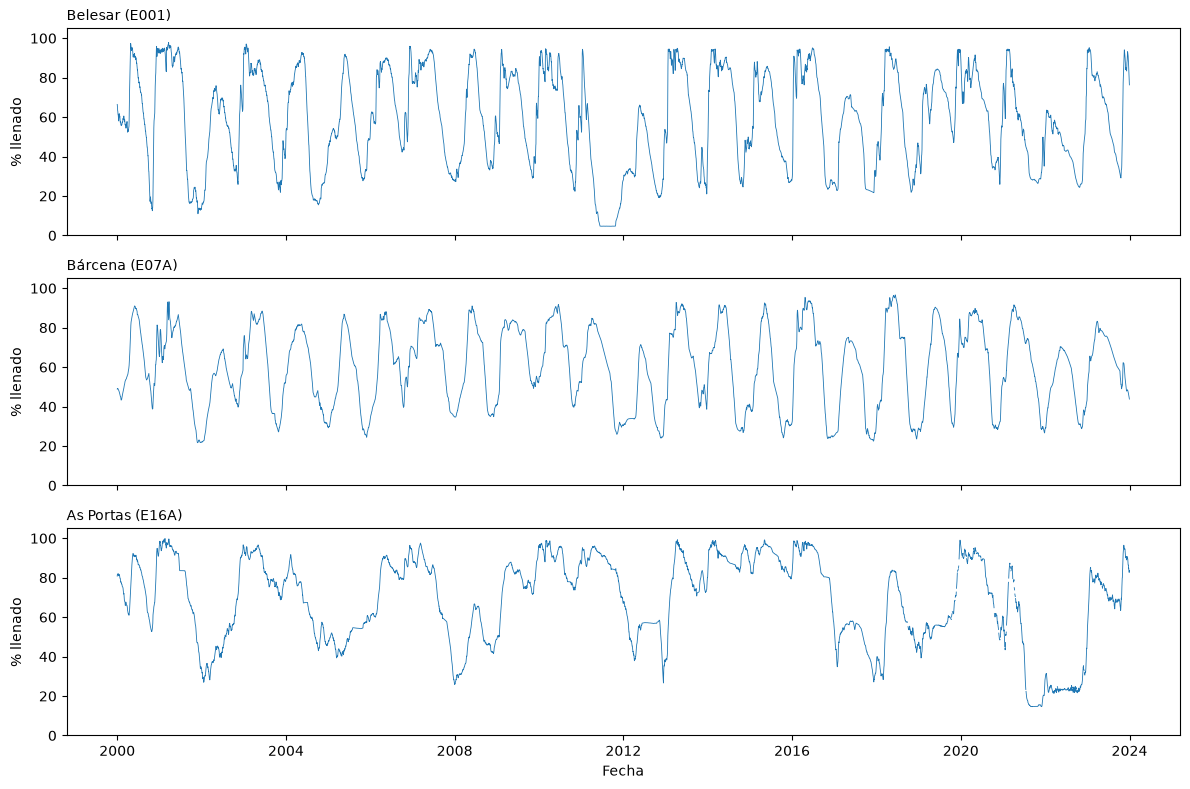

In [2]:
embalses_focus = ["E001", "E07A", "E16A"]  # Belesar, Bárcena, As Portas
nombres = {"E001": "Belesar", "E07A": "Bárcena", "E16A": "As Portas"}

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, emb in zip(axes, embalses_focus):
    d = dataset[dataset["ID_SAIH"] == emb]
    ax.plot(d["fecha"], d["pct_llenado"], linewidth=0.6, color="#1f77b4")
    ax.set_title(f"{nombres[emb]} ({emb})", fontsize=10, loc="left")
    ax.set_ylabel("% llenado")
    ax.set_ylim(0, 105)
axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.savefig(DIR_OUTPUTS / "5_3_series_representativas.png", dpi=150, bbox_inches="tight")
plt.show()

## Patrón estacional

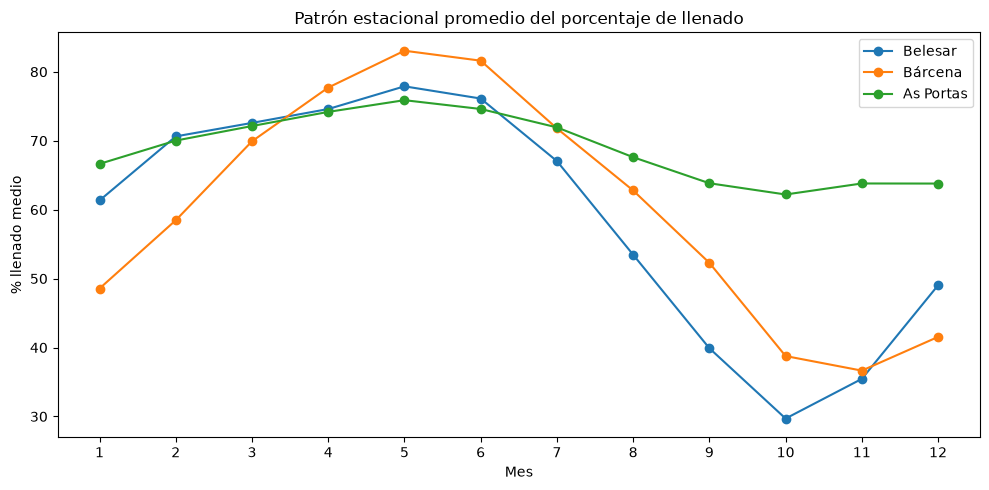

In [3]:
d_focus = dataset[dataset["ID_SAIH"].isin(embalses_focus)].copy()
d_focus["mes"] = d_focus["fecha"].dt.month
estacional = d_focus.groupby(["ID_SAIH", "mes"])["pct_llenado"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for emb in embalses_focus:
    e = estacional[estacional["ID_SAIH"] == emb]
    ax.plot(e["mes"], e["pct_llenado"], marker="o", label=nombres[emb])
ax.set_xlabel("Mes")
ax.set_ylabel("% llenado medio")
ax.set_xticks(range(1, 13))
ax.legend()
ax.set_title("Patrón estacional promedio del porcentaje de llenado")
plt.tight_layout()
plt.savefig(DIR_OUTPUTS / "5_3_patron_estacional.png", dpi=150, bbox_inches="tight")
plt.show()

## Boxplot de distribución por embalse

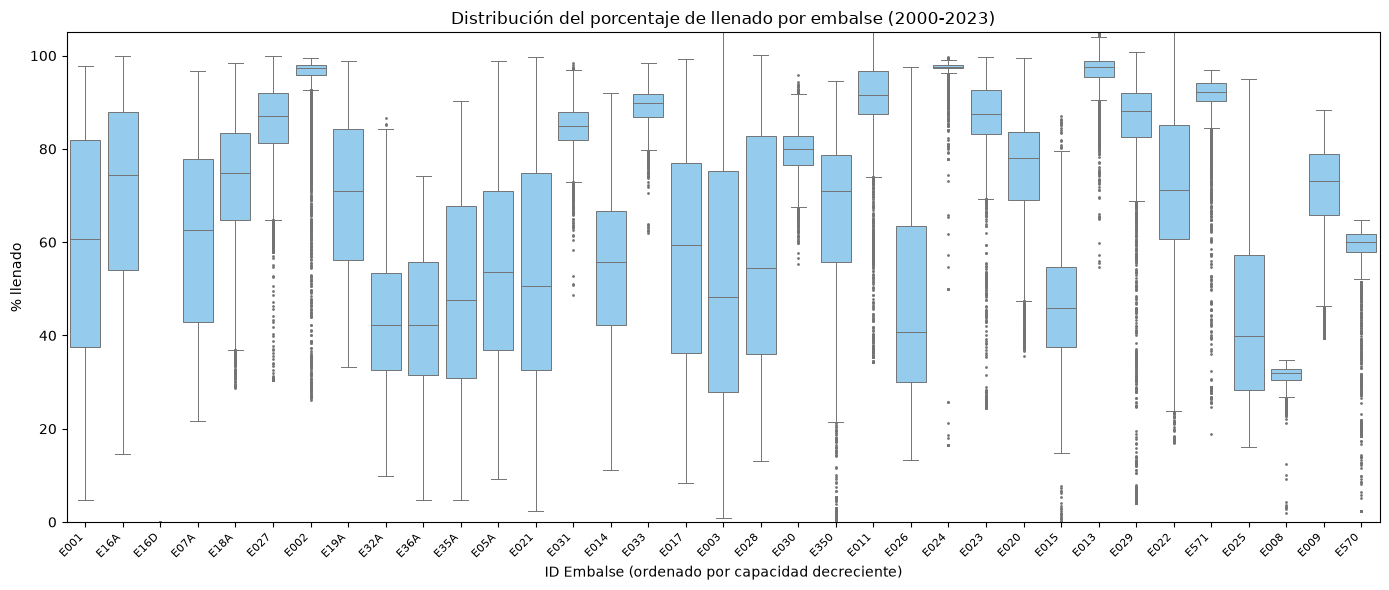

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
orden = maestro.sort_values("Capacidad_hm3", ascending=False)["ID_SAIH"].tolist()
orden = [i for i in orden if i in dataset["ID_SAIH"].unique()]

sns.boxplot(data=dataset, x="ID_SAIH", y="pct_llenado", order=orden,
            ax=ax, color="#87cefa", linewidth=0.7, fliersize=1)
ax.set_xlabel("ID Embalse (ordenado por capacidad decreciente)")
ax.set_ylabel("% llenado")
ax.set_title("Distribución del porcentaje de llenado por embalse (2000-2023)")
ax.set_ylim(0, 105)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(DIR_OUTPUTS / "5_3_distribucion_llenado.png", dpi=150, bbox_inches="tight")
plt.show()

## Estadísticos por embalse

In [5]:
stats = dataset.groupby(["ID_SAIH", "Nombre_SAIH"]).agg(
    n_dias=("pct_llenado", "count"),
    media=("pct_llenado", "mean"),
    mediana=("pct_llenado", "median"),
    minimo=("pct_llenado", "min"),
    maximo=("pct_llenado", "max"),
).round(2).reset_index()

stats = stats.merge(maestro[["ID_SAIH", "Capacidad_hm3"]], on="ID_SAIH")
stats = stats.sort_values("Capacidad_hm3", ascending=False)
print(stats.to_string(index=False))

ID_SAIH            Nombre_SAIH  n_dias  media  mediana  minimo  maximo  Capacidad_hm3
   E001                Belesar    8766  58.92    60.75    4.65   97.88         645.56
   E16A      As Portas - Presa    8684  68.88    74.45   14.64   99.90         535.71
   E16D As Portas - C.H. Conso    8526   0.03     0.03    0.01    0.04         535.71
   E07A       Presa de Bárcena    8766  60.25    62.62   21.70   96.61         341.46
   E18A            Bao - Presa    8668  72.88    74.75   28.74   98.42         238.10
   E027            San Esteban    8680  84.93    87.08   30.46  100.02         213.23
   E002              Os Peares    8766  94.33    97.29   26.09   99.53         182.00
   E19A          Prada - Presa    8766  69.81    70.96   33.26   98.95         122.00
   E32A     Albarellos - Presa    8766  43.23    42.25    9.95   86.65          90.73
   E36A          Salas - Presa    8766  43.00    42.26    4.70   74.18          86.67
   E35A        Conchas - Presa    8766  49.32    47.59

# Completitud

## Función de rachas de ausencia

In [6]:
def rachas_por_variable(df, var):
    """Longitudes de las rachas de ausencia de una variable, por embalse."""
    filas = []
    for emb, g in df.groupby("ID_SAIH"):
        nulo = g[var].isna()
        if not nulo.any():
            continue
        grupo = (nulo != nulo.shift()).cumsum()
        for _, s in g[nulo].groupby(grupo[nulo]):
            filas.append({"ID_SAIH": emb, "dias": len(s),
                          "desde": s["fecha"].min(), "hasta": s["fecha"].max()})
    return pd.DataFrame(filas)

VARIABLES = ["pct_llenado", "aportacion_m3s", "salida_m3s",
             "aemet_precipitacion_mm", "aemet_temp_media_c",
             "aemet_humedad_pct", "aemet_viento_ms",
             "aemet_insolacion_h", "aemet_presion_max_hpa"]

MAX_RACHA_IMPUTABLE = 5
resumen = []
rachas = {}
for var in VARIABLES:
    r = rachas_por_variable(dataset, var)
    rachas[var] = r
    resumen.append({
        "variable": var,
        "cobertura_%": round(dataset[var].notna().mean() * 100, 1),
        "n_rachas": len(r),
        "racha_max_dias": int(r["dias"].max()) if len(r) else 0,
    })
print(pd.DataFrame(resumen).to_string(index=False))

              variable  cobertura_%  n_rachas  racha_max_dias
           pct_llenado         96.1      1021            4291
        aportacion_m3s         86.0      1411            4291
            salida_m3s         95.6      1161            4291
aemet_precipitacion_mm         92.5      3999            2548
    aemet_temp_media_c         92.9      2456            2548
     aemet_humedad_pct         87.3      3003            3196
       aemet_viento_ms         76.1      3341            8766
    aemet_insolacion_h         47.6      1720            8766
 aemet_presion_max_hpa         61.6      6145            8766


## Bloques prolongados, sin lógica de experimentales

In [7]:
largos = pd.concat(
    [r[r["dias"] > MAX_RACHA_IMPUTABLE].assign(variable=v) for v, r in rachas.items()],
    ignore_index=True)

print(f"Bloques prolongados (> {MAX_RACHA_IMPUTABLE} días): {len(largos)}\n")
print("=== Los 15 mayores ===")
print(largos.nlargest(15, "dias")[["variable", "ID_SAIH", "dias", "desde", "hasta"]]
      .assign(desde=lambda d: d["desde"].dt.date, hasta=lambda d: d["hasta"].dt.date)
      .to_string(index=False))

Bloques prolongados (> 5 días): 2546

=== Los 15 mayores ===
             variable ID_SAIH  dias      desde      hasta
      aemet_viento_ms    E35A  8766 2000-01-01 2023-12-31
      aemet_viento_ms    E571  8766 2000-01-01 2023-12-31
   aemet_insolacion_h    E001  8766 2000-01-01 2023-12-31
   aemet_insolacion_h    E028  8766 2000-01-01 2023-12-31
   aemet_insolacion_h    E033  8766 2000-01-01 2023-12-31
   aemet_insolacion_h    E16A  8766 2000-01-01 2023-12-31
   aemet_insolacion_h    E32A  8766 2000-01-01 2023-12-31
   aemet_insolacion_h    E35A  8766 2000-01-01 2023-12-31
   aemet_insolacion_h    E36A  8766 2000-01-01 2023-12-31
   aemet_insolacion_h    E571  8766 2000-01-01 2023-12-31
aemet_presion_max_hpa    E001  8766 2000-01-01 2023-12-31
aemet_presion_max_hpa    E028  8766 2000-01-01 2023-12-31
aemet_presion_max_hpa    E033  8766 2000-01-01 2023-12-31
aemet_presion_max_hpa    E16A  8766 2000-01-01 2023-12-31
aemet_presion_max_hpa    E32A  8766 2000-01-01 2023-12-31


## Cobertura por variable sobre los 35

In [8]:
print("Cobertura de cada variable sobre los 35 embalses (2000-2023):\n")
todas = [c for c in dataset.columns if c not in ["fecha", "ID_SAIH", "Nombre_SAIH", "Sistema", "Capacidad_hm3"]]
for c in todas:
    print(f"  {c:<32} {dataset[c].notna().mean()*100:5.1f}%")

Cobertura de cada variable sobre los 35 embalses (2000-2023):

  volumen_hm3                       96.1%
  pct_llenado                       96.1%
  aportacion_m3s                    86.0%
  salida_m3s                        95.6%
  aemet_temp_media_c                92.9%
  aemet_temp_min_c                  92.9%
  aemet_temp_max_c                  92.9%
  aemet_precipitacion_mm            92.5%
  aemet_humedad_pct                 87.3%
  aemet_viento_ms                   76.1%
  aemet_insolacion_h                47.6%
  aemet_presion_max_hpa             61.6%
  aemet_presion_min_hpa             61.6%
  cal_arriba_amonio_mgl             19.5%
  cal_arriba_conductividad_uscm     21.9%
  cal_arriba_fosfatos_mgl            1.7%
  cal_arriba_materia_organica_m1     3.2%
  cal_arriba_oxigeno_mgl            21.6%
  cal_arriba_ph                     21.9%
  cal_arriba_temp_agua_c            22.0%
  cal_arriba_turbidez_ntu           21.5%
  cal_abajo_amonio_mgl              28.8%
  cal_abajo_c

In [9]:
# ¿Dónde está la racha de 4291 días en el llenado?
print(rachas["pct_llenado"].nlargest(5, "dias")[["ID_SAIH", "dias", "desde", "hasta"]].to_string(index=False))

ID_SAIH  dias      desde      hasta
   E05A  4291 2000-01-01 2011-09-30
   E003  3288 2000-01-01 2008-12-31
   E024  2191 2018-01-01 2023-12-31
   E003   942 2009-02-01 2011-08-31
   E16D   152 2002-05-01 2002-09-29


In [10]:
# Bloques largos agrupados por embalse (cuántos días de ausencia acumulan en variables clave)
clave = largos[largos["variable"].isin(["pct_llenado", "aportacion_m3s"])]
print(clave.groupby("ID_SAIH")["dias"].sum().sort_values(ascending=False).head(10).to_string())

ID_SAIH
E05A    8582
E003    8491
E024    6574
E021    2208
E570    2206
E011    2192
E020    2192
E017    2192
E014    2192
E015    2192


In [11]:
# Separar por variable para esos embalses
for emb in ["E021", "E570", "E011", "E020", "E017", "E014", "E015"]:
    for var in ["pct_llenado", "aportacion_m3s"]:
        sub = rachas[var]
        d = sub[sub["ID_SAIH"] == emb]["dias"].sum() if len(sub[sub["ID_SAIH"]==emb]) else 0
        if d > 100:
            print(f"{emb} {var}: {d} días")

E021 pct_llenado: 106 días
E021 aportacion_m3s: 2329 días
E570 aportacion_m3s: 2309 días
E011 aportacion_m3s: 2192 días
E020 aportacion_m3s: 2303 días
E017 aportacion_m3s: 2359 días
E014 aportacion_m3s: 2195 días
E015 aportacion_m3s: 2197 días


In [12]:
# Análisis completo de bloques largos de ausencia: qué variable falta, en qué embalse y cuándo
# Para cada variable y embalse, el mayor bloque de ausencia y su periodo

filas = []
for var in VARIABLES:
    r = rachas[var]
    if len(r) == 0:
        continue
    for emb, g in r.groupby("ID_SAIH"):
        total = g["dias"].sum()
        mayor = g.loc[g["dias"].idxmax()]
        filas.append({
            "variable": var,
            "ID_SAIH": emb,
            "dias_ausentes_total": int(total),
            "mayor_bloque_dias": int(mayor["dias"]),
            "desde": mayor["desde"].date(),
            "hasta": mayor["hasta"].date(),
        })

detalle = pd.DataFrame(filas)

# Filtrar solo bloques relevantes (más de 180 días de ausencia total) para ver los estructurales
relevantes = detalle[detalle["dias_ausentes_total"] > 180].sort_values(
    ["variable", "dias_ausentes_total"], ascending=[True, False])

print("=== Ausencias estructurales por variable y embalse (>180 días totales) ===\n")
for var in VARIABLES:
    sub = relevantes[relevantes["variable"] == var]
    if len(sub) == 0:
        continue
    print(f"--- {var} ({len(sub)} embalses afectados) ---")
    print(sub[["ID_SAIH", "dias_ausentes_total", "mayor_bloque_dias", "desde", "hasta"]].to_string(index=False))
    print()

=== Ausencias estructurales por variable y embalse (>180 días totales) ===

--- pct_llenado (4 embalses afectados) ---
ID_SAIH  dias_ausentes_total  mayor_bloque_dias      desde      hasta
   E05A                 4291               4291 2000-01-01 2011-09-30
   E003                 4230               3288 2000-01-01 2008-12-31
   E024                 2191               2191 2018-01-01 2023-12-31
   E16D                  240                152 2002-05-01 2002-09-29

--- aportacion_m3s (17 embalses afectados) ---
ID_SAIH  dias_ausentes_total  mayor_bloque_dias      desde      hasta
   E024                 4383               2192 2000-01-01 2005-12-31
   E05A                 4291               4291 2000-01-01 2011-09-30
   E003                 4261               4261 2000-01-01 2011-08-31
   E017                 2359               2192 2000-01-01 2005-12-31
   E021                 2329               2192 2000-01-01 2005-12-31
   E570                 2309               2192 2000-01-01 2005

In [13]:
# ¿Cuántos embalses tienen aportación ausente principalmente antes de 2006?
apor = rachas["aportacion_m3s"]
pre2006 = apor[apor["hasta"] < pd.Timestamp("2006-01-01")]
print("Embalses con bloques de aportación ausente que terminan antes de 2006:")
print(pre2006.groupby("ID_SAIH")["dias"].sum().sort_values(ascending=False).to_string())
print(f"\nTotal embalses afectados solo antes de 2006: {pre2006['ID_SAIH'].nunique()}")

Embalses con bloques de aportación ausente que terminan antes de 2006:
ID_SAIH
E011    2192
E014    2192
E015    2192
E017    2192
E020    2192
E021    2192
E022    2192
E024    2192
E025    2192
E026    2192
E350    2192
E571    2192
E570    2192
E028    1852
E16D     152

Total embalses afectados solo antes de 2006: 15


## Tabla resumen de completitud por variable

In [14]:
# Tabla de completitud descriptiva 
grupos = {
    "Hidrológicas": ["pct_llenado", "volumen_hm3", "aportacion_m3s", "salida_m3s"],
    "Meteorológicas": ["aemet_temp_media_c", "aemet_temp_min_c", "aemet_temp_max_c",
                       "aemet_precipitacion_mm", "aemet_humedad_pct",
                       "aemet_viento_ms", "aemet_insolacion_h",
                       "aemet_presion_max_hpa", "aemet_presion_min_hpa"],
    "Calidad (aguas arriba)": [c for c in dataset.columns if c.startswith("cal_arriba")],
    "Calidad (aguas abajo)": [c for c in dataset.columns if c.startswith("cal_abajo")],
}

filas = []
n_emb = dataset["ID_SAIH"].nunique()
for grupo, cols in grupos.items():
    for c in cols:
        if c not in dataset.columns:
            continue
        cob = dataset[c].notna().mean() * 100
        # embalses con al menos un dato de la variable
        con_dato = dataset.groupby("ID_SAIH")[c].apply(lambda s: s.notna().any()).sum()
        filas.append({
            "Grupo": grupo,
            "Variable": c.replace("aemet_", "").replace("cal_arriba_", "").replace("cal_abajo_", ""),
            "Cobertura (%)": round(cob, 1),
            "Embalses con dato": f"{con_dato}/{n_emb}",
        })

tabla = pd.DataFrame(filas)
print(tabla.to_string(index=False))

                 Grupo            Variable  Cobertura (%) Embalses con dato
          Hidrológicas         pct_llenado           96.1             35/35
          Hidrológicas         volumen_hm3           96.1             35/35
          Hidrológicas      aportacion_m3s           86.0             35/35
          Hidrológicas          salida_m3s           95.6             35/35
        Meteorológicas        temp_media_c           92.9             35/35
        Meteorológicas          temp_min_c           92.9             35/35
        Meteorológicas          temp_max_c           92.9             35/35
        Meteorológicas    precipitacion_mm           92.5             35/35
        Meteorológicas         humedad_pct           87.3             35/35
        Meteorológicas           viento_ms           76.1             33/35
        Meteorológicas        insolacion_h           47.6             27/35
        Meteorológicas     presion_max_hpa           61.6             28/35
        Mete

## Figura: mapa de calor de completitud por variable y embalse

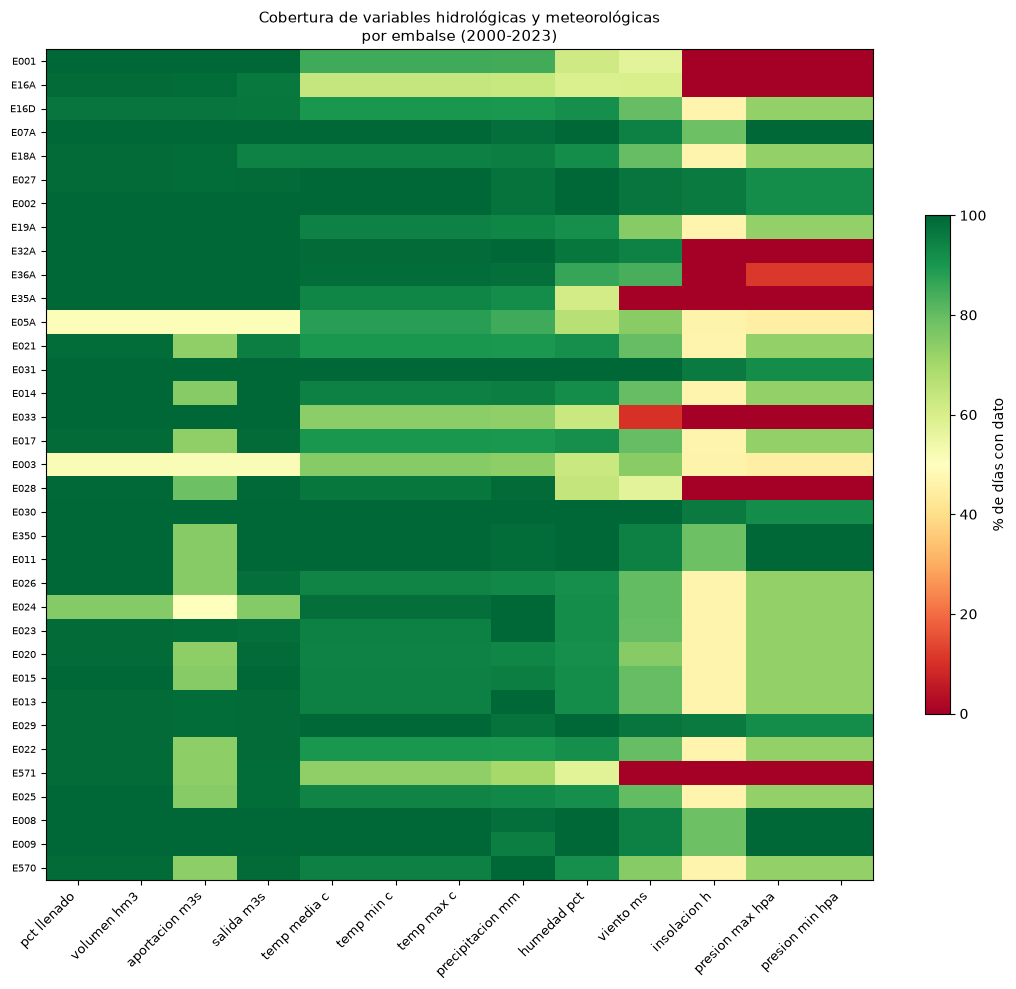

In [15]:
vars_hidro_meteo = ["pct_llenado", "volumen_hm3", "aportacion_m3s", "salida_m3s",
                    "aemet_temp_media_c", "aemet_temp_min_c", "aemet_temp_max_c",
                    "aemet_precipitacion_mm", "aemet_humedad_pct",
                    "aemet_viento_ms", "aemet_insolacion_h",
                    "aemet_presion_max_hpa", "aemet_presion_min_hpa"]

orden_emb = maestro.sort_values("Capacidad_hm3", ascending=False)["ID_SAIH"].tolist()
orden_emb = [e for e in orden_emb if e in dataset["ID_SAIH"].unique()]

cob = (dataset.groupby("ID_SAIH")[vars_hidro_meteo]
       .apply(lambda g: g.notna().mean() * 100).reindex(orden_emb))

fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(cob.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
ax.set_xticks(range(len(vars_hidro_meteo)))
ax.set_xticklabels([v.replace("aemet_", "").replace("_", " ") for v in vars_hidro_meteo],
                   rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(orden_emb)))
ax.set_yticklabels(orden_emb, fontsize=7)
ax.set_title("Cobertura de variables hidrológicas y meteorológicas\npor embalse (2000-2023)", fontsize=11)
cbar = fig.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label("% de días con dato")
plt.tight_layout()
plt.savefig(DIR_OUTPUTS / "5_3_completitud_hidro_meteo.png", dpi=150, bbox_inches="tight")
plt.show()

## Figura: disponibilidad temporal de la aportación

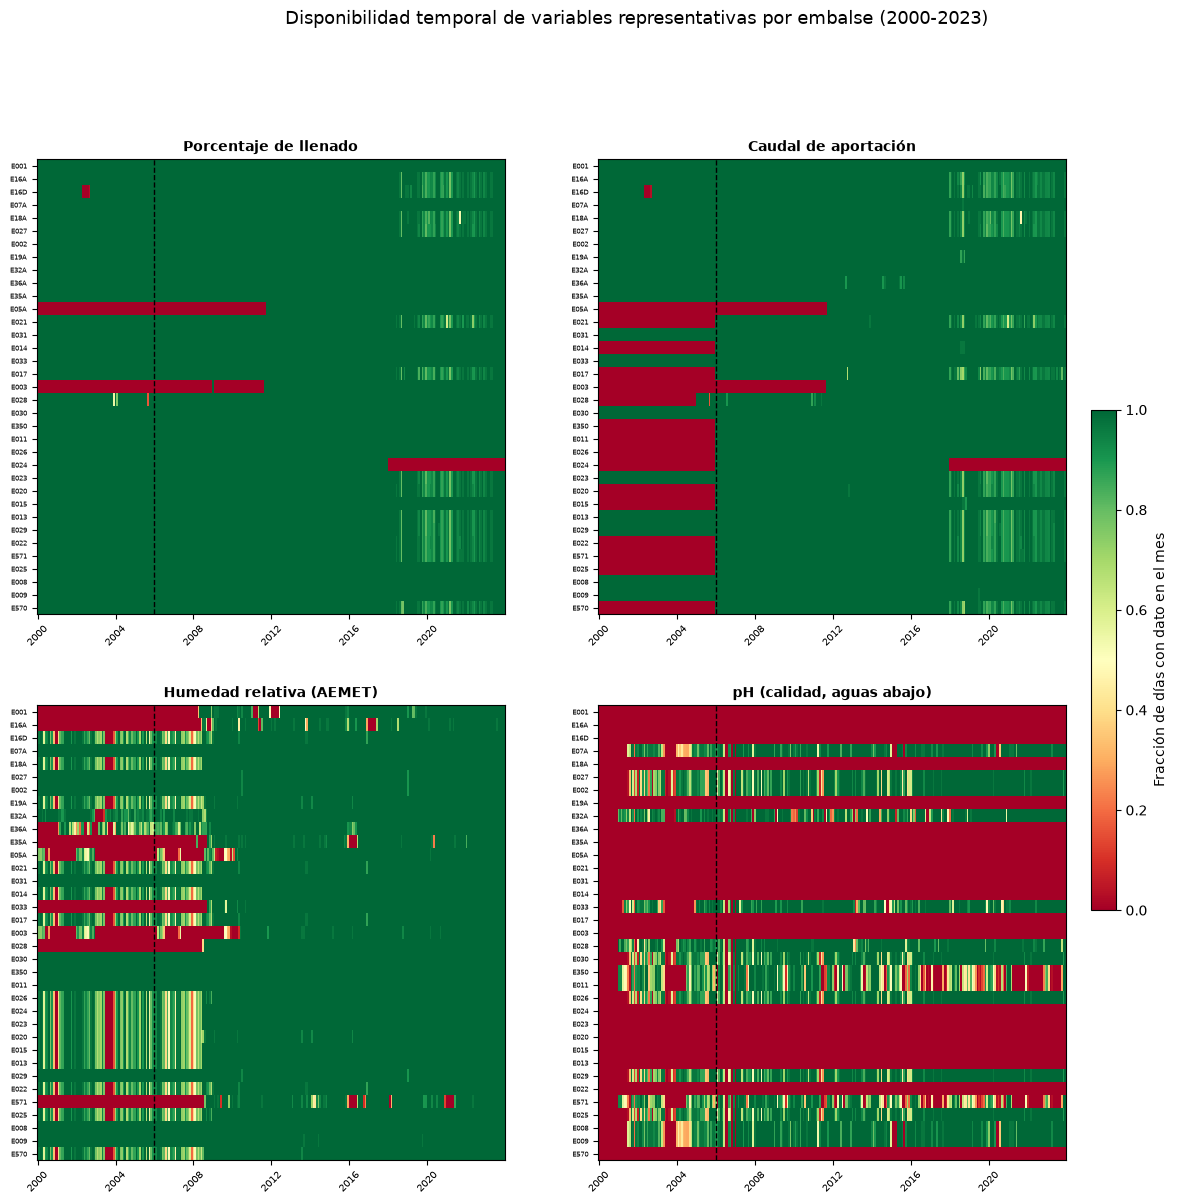

In [16]:
import numpy as np

variables_panel = [
    ("pct_llenado", "Porcentaje de llenado"),
    ("aportacion_m3s", "Caudal de aportación"),
    ("aemet_humedad_pct", "Humedad relativa (AEMET)"),
    ("cal_abajo_ph", "pH (calidad, aguas abajo)"),
]

orden_emb = maestro.sort_values("Capacidad_hm3", ascending=False)["ID_SAIH"].tolist()

d = dataset.copy()
d["anio_mes"] = d["fecha"].dt.to_period("M")

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()

for ax, (var, titulo) in zip(axes, variables_panel):
    disp = (d.groupby(["ID_SAIH", "anio_mes"])[var]
            .apply(lambda s: s.notna().mean())
            .unstack(fill_value=0))
    emb = [e for e in orden_emb if e in disp.index]
    disp = disp.reindex(emb)

    im = ax.imshow(disp.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1,
                   interpolation="nearest")

    meses = disp.columns.to_timestamp()
    anios = sorted(set(meses.year))
    ticks = [np.argmin(np.abs(meses - pd.Timestamp(f"{a}-01-01"))) for a in anios if a % 4 == 0]
    ax.set_xticks(ticks)
    ax.set_xticklabels([a for a in anios if a % 4 == 0], rotation=45, fontsize=7)
    ax.set_yticks(range(len(emb)))
    ax.set_yticklabels(emb, fontsize=5)

    # línea en 2006
    idx_2006 = np.argmin(np.abs(meses - pd.Timestamp("2006-01-01")))
    ax.axvline(idx_2006, color="black", linestyle="--", linewidth=1)

    ax.set_title(titulo, fontsize=10, fontweight="bold")

fig.suptitle("Disponibilidad temporal de variables representativas por embalse (2000-2023)",
             fontsize=13, y=0.995)
fig.colorbar(im, ax=axes, shrink=0.5, label="Fracción de días con dato en el mes",
             location="right", pad=0.02)
plt.savefig(DIR_OUTPUTS / "5_3_disponibilidad_composicion.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Correlación (básica)

In [17]:
# 5.3.3 - Correlación directa de las variables con el porcentaje de llenado (exploración inicial)
# Sobre el dataset completo observado, pairwise (.corr ignora NaN par a par)

# Bloque único de calidad (arriba con prioridad, abajo en su defecto)
PARAMETROS_CAL = ["amonio_mgl", "conductividad_uscm", "oxigeno_mgl",
                  "ph", "temp_agua_c", "turbidez_ntu"]
for p in PARAMETROS_CAL:
    dataset[f"cal_{p}"] = dataset[f"cal_arriba_{p}"].fillna(dataset[f"cal_abajo_{p}"])

# Variables a correlacionar con el llenado (las observadas disponibles)
vars_corr = ["aportacion_m3s", "salida_m3s",
             "aemet_temp_media_c", "aemet_precipitacion_mm", "aemet_humedad_pct",
             "aemet_viento_ms", "aemet_insolacion_h", "aemet_presion_max_hpa"] + \
            [f"cal_{p}" for p in PARAMETROS_CAL]

corr = (dataset[vars_corr + ["pct_llenado"]].corr()["pct_llenado"]
        .drop("pct_llenado").sort_values(key=abs, ascending=False))

print("Correlación directa con el porcentaje de llenado (dataset completo, observado):\n")
print(corr.round(3).to_string())

Correlación directa con el porcentaje de llenado (dataset completo, observado):

aemet_presion_max_hpa     0.337
aportacion_m3s            0.301
salida_m3s                0.298
cal_oxigeno_mgl           0.196
cal_ph                    0.136
aemet_temp_media_c        0.071
cal_turbidez_ntu          0.068
cal_amonio_mgl           -0.057
cal_temp_agua_c          -0.057
cal_conductividad_uscm   -0.037
aemet_viento_ms          -0.025
aemet_humedad_pct        -0.024
aemet_insolacion_h       -0.010
aemet_precipitacion_mm    0.004


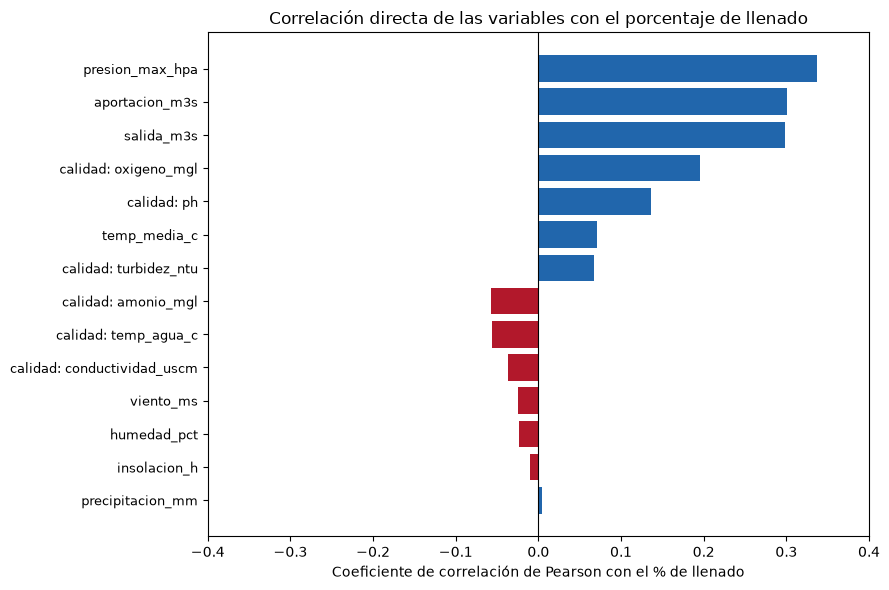

In [18]:
# Figura: correlaciones directas con el llenado (barras horizontales)
fig, ax = plt.subplots(figsize=(9, 6))
colores = ["#2166ac" if v > 0 else "#b2182b" for v in corr.values]
ax.barh(range(len(corr)), corr.values, color=colores)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels([v.replace("aemet_", "").replace("cal_", "calidad: ") for v in corr.index], fontsize=9)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coeficiente de correlación de Pearson con el % de llenado")
ax.set_title("Correlación directa de las variables con el porcentaje de llenado")
ax.invert_yaxis()
ax.set_xlim(-0.4, 0.4)
plt.tight_layout()
plt.savefig(DIR_OUTPUTS / "5_3_correlaciones_directas.png", dpi=150, bbox_inches="tight")
plt.show()

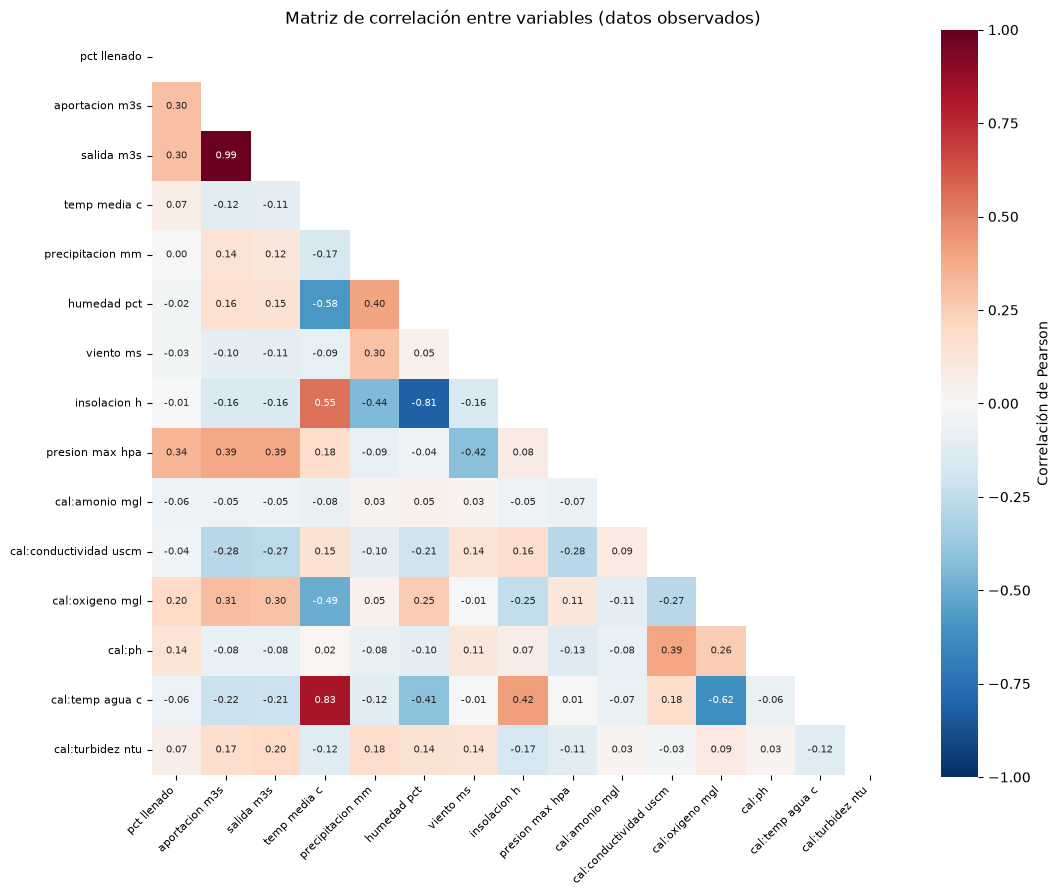

In [19]:
import seaborn as sns

# Matriz de correlación completa (pairwise sobre observados)
vars_matriz = ["pct_llenado", "aportacion_m3s", "salida_m3s",
               "aemet_temp_media_c", "aemet_precipitacion_mm", "aemet_humedad_pct",
               "aemet_viento_ms", "aemet_insolacion_h", "aemet_presion_max_hpa"] + \
              [f"cal_{p}" for p in PARAMETROS_CAL]

matriz = dataset[vars_matriz].corr()

# Etiquetas legibles
etiquetas = [v.replace("aemet_", "").replace("cal_", "cal:").replace("_", " ") for v in vars_matriz]

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(matriz, dtype=bool))  # solo triángulo inferior
sns.heatmap(matriz, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True,
            xticklabels=etiquetas, yticklabels=etiquetas,
            cbar_kws={"label": "Correlación de Pearson"}, annot_kws={"size": 7}, ax=ax)
ax.set_title("Matriz de correlación entre variables (datos observados)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(DIR_OUTPUTS / "5_3_matriz_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()